<a href="https://colab.research.google.com/github/fmakkawi/Data-205/blob/main/DATA205_Capstone_FarahMakkawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project analyzes the relationship between education, income, population, and internet access across Maryland counties. The main goal is to understand how these factors are connected and how they differ between counties, with a focus on comparing Montgomery County and Prince George’s County.

In [6]:
# Farah Makkawi
# DATA 205 Capstone Project

from google.colab import files

uploaded = files.upload()

Saving internet_data.csv to internet_data (1).csv


In [7]:
from google.colab import files

uploaded = files.upload()

Saving income_data.csv to income_data (1).csv


In [8]:
from google.colab import files

uploaded = files.upload()

Saving population_data.csv to population_data (1).csv


In [9]:
from google.colab import files

uploaded = files.upload()

Saving education_data.csv to education_data (1).csv


In [10]:
import pandas as pd

# Load datasets (IMPORTANT: skiprows=1 for Census files)
income = pd.read_csv("income_data.csv", skiprows=[1])
population = pd.read_csv("population_data.csv", skiprows=[1])
education = pd.read_csv("education_data.csv", skiprows=[1])
internet = pd.read_csv("internet_data.csv", skiprows=[1])

# Check they loaded correctly
print("Income:", income.shape)
print("Population:", population.shape)
print("Education:", education.shape)
print("Internet:", internet.shape)

Income: (24, 131)
Population: (24, 379)
Education: (24, 771)
Internet: (24, 127)


In [11]:
# Select important columns

income_clean = income[["NAME", "S1901_C01_012E"]].rename(columns={
    "S1901_C01_012E": "Median_Income"
})

population_clean = population[["NAME", "DP05_0001E"]].rename(columns={
    "DP05_0001E": "Population"
})

education_clean = education[["NAME", "S1501_C02_015E"]].rename(columns={
    "S1501_C02_015E": "Bachelors_Percent"
})

internet_clean = internet[["NAME", "S2801_C02_014E"]].rename(columns={
    "S2801_C02_014E": "Internet_Access_Percent"
})

# Preview
income_clean.head()

,NAME,Median_Income
0,"Allegany County, Maryland",57393
1,"Anne Arundel County, Maryland",120324
2,"Baltimore County, Maryland",90904
3,"Calvert County, Maryland",132059
4,"Caroline County, Maryland",66368


In [12]:
# Merge all datasets

df = income_clean.merge(population_clean, on="NAME")
df = df.merge(education_clean, on="NAME")
df = df.merge(internet_clean, on="NAME")

# Preview final dataset
df.head()

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
0,"Allegany County, Maryland",57393,67762,21.1,83.8
1,"Anne Arundel County, Maryland",120324,590936,45.2,94.9
2,"Baltimore County, Maryland",90904,849586,41.4,90.5
3,"Calvert County, Maryland",132059,93791,35.3,92.9
4,"Caroline County, Maryland",66368,33406,17.6,86.3


In [13]:
# Filter the two counties

target = df[
    df["NAME"].isin([
        "Montgomery County, Maryland",
        "Prince George's County, Maryland"
    ])
]

target

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
14,"Montgomery County, Maryland",128733,1057586,60.3,95.3
15,"Prince George's County, Maryland",100708,955584,36.1,92.9


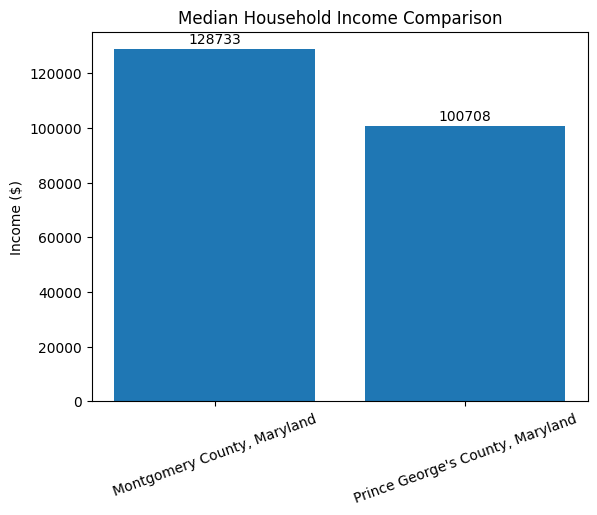

In [16]:
# Improved bar chart with labels

plt.figure()

bars = plt.bar(target["NAME"], target["Median_Income"])

plt.title("Median Household Income Comparison")
plt.ylabel("Income ($)")
plt.xticks(rotation=20)

# Add values on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 2000, f"{int(y)}", ha='center')

plt.show()

Montgomery County has a higher median household income (about $128,000) compared to Prince George’s County (about $100,000). This shows a clear economic difference between the two counties.

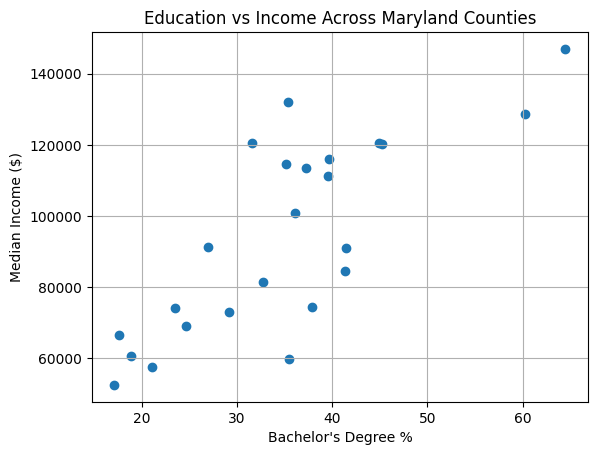

In [20]:
# Scatter plot using ALL counties

plt.figure()

plt.scatter(
    df["Bachelors_Percent"],
    df["Median_Income"]
)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Education vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between education and income across all Maryland counties. There is a clear upward trend, meaning that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. This suggests a positive relationship between education level and income.

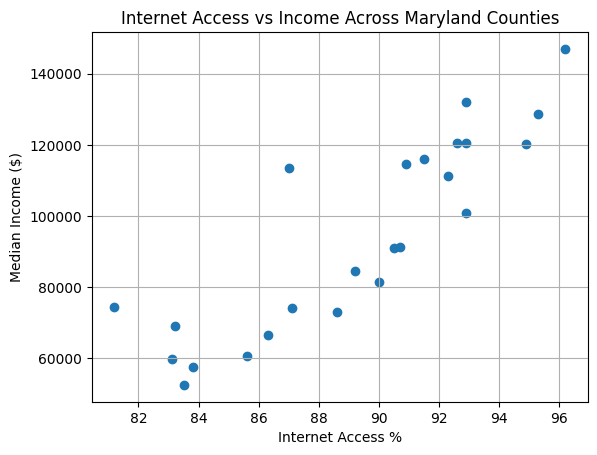

In [21]:
# Internet vs Income

plt.figure()

plt.scatter(
    df["Internet_Access_Percent"],
    df["Median_Income"]
)

plt.xlabel("Internet Access %")
plt.ylabel("Median Income ($)")
plt.title("Internet Access vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between internet access and income across Maryland counties. There is a clear upward trend, indicating that counties with higher internet access tend to have higher median household incomes. This suggests that access to technology may be linked to better economic opportunities and higher income levels.

Overall, the analysis shows that education, internet access, and income are closely related. Counties with higher education levels and better internet access tend to have higher median household incomes. This suggests that both education and access to technology play an important role in economic outcomes across Maryland counties.

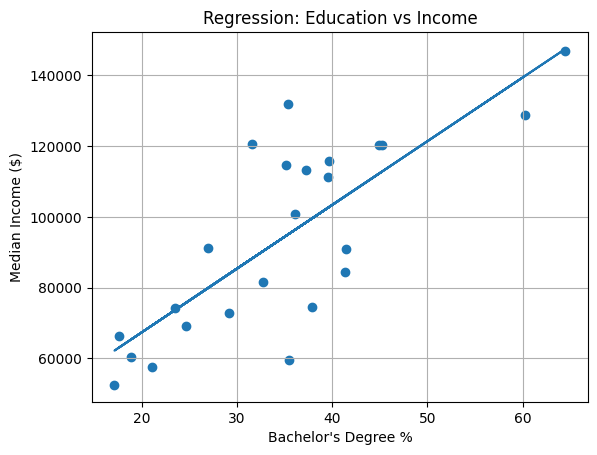

Slope: 1800.2333717434267
Intercept: 31383.988105212524


In [23]:
# Simple regression: Education → Income

import numpy as np

# X = education, y = income
x = df["Bachelors_Percent"]
y = df["Median_Income"]

# Fit line
m, b = np.polyfit(x, y, 1)

# Plot
plt.figure()
plt.scatter(x, y)

# regression line
plt.plot(x, m*x + b)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Regression: Education vs Income")

plt.grid()
plt.show()

# Print equation
print("Slope:", m)
print("Intercept:", b)

A regression analysis was performed to examine the relationship between education and income. The results show a positive slope of approximately 1800, meaning that for every 1% increase in the percentage of residents with a bachelor’s degree, median household income increases by about $1,800. This confirms a strong positive relationship between education and income across Maryland counties.

In the regression model, the intercept (b) is approximately 31,383. This represents the estimated median income when the percentage of residents with a bachelor’s degree is zero. While this value may not be realistic in practice, it is part of the regression equation used to model the relationship between education and income.

In [25]:
# Correlation
corr = df["Bachelors_Percent"].corr(df["Median_Income"])
print("Correlation:", corr)

Correlation: 0.7816288020850959


The correlation coefficient is approximately 0.78, indicating a strong positive relationship between education and income. This means that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes.

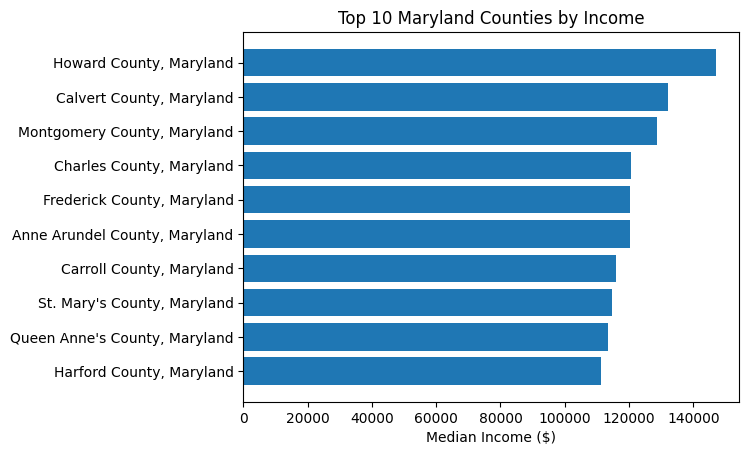

In [26]:
# Top counties by income

top = df.sort_values("Median_Income", ascending=False).head(10)

plt.figure()
plt.barh(top["NAME"], top["Median_Income"])

plt.xlabel("Median Income ($)")
plt.title("Top 10 Maryland Counties by Income")

plt.gca().invert_yaxis()
plt.show()

This chart shows the top 10 Maryland counties by median household income. Howard County has the highest median income, followed by Calvert and Montgomery counties. Most of the top counties are located in central Maryland, suggesting that income levels are higher in areas closer to major economic centers. This highlights geographic differences in income across the state.

In conclusion, this analysis shows that there is a strong positive relationship between education and income across Maryland counties. Counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. Internet access also shows a positive relationship with income, indicating that more developed areas have better access to technology.

When comparing Montgomery County and Prince George’s County, Montgomery County has higher income, higher education levels, and slightly higher internet access. This suggests differences in economic development between the two counties.

Overall, the results demonstrate how education and access to resources are important factors in understanding income differences across regions.